# Qualidade do Ar nas Grandes Cidades Brasileiras (2015–2024)
### Projeto G1 – Análise e Visualização de Dados com Python · Tema 08

**Disciplina:** Linguagem de Programação – Análise e Visualização de Dados com Python  
**Professor:** Alexandre Neves Louzada  
**Aluno:** Gabriel Hierro Amorim dos Santos  
**Mês e Ano:** Outubro / 2026

# 1. Introdução ao Problema

A qualidade do ar é um dos indicadores mais diretos da relação entre a atividade urbana e a saúde da população. Grandes centros concentram tráfego intenso, indústrias, construção civil e, em algumas regiões, a influência de queimadas, o que eleva a concentração de poluentes na atmosfera.

Este projeto analisa **120 meses (2015–2024) de medições simuladas em 37 cidades brasileiras**, distribuídas pelas cinco regiões do país, com o objetivo de apoiar a identificação de cidades e períodos que exigem maior atenção ambiental.

**Perguntas orientadoras**

1. Quais cidades apresentam pior qualidade do ar?
2. Existem períodos mais críticos (meses ou anos)?
3. Quais poluentes são mais frequentes e mais determinantes para o índice?
4. Existe relação entre clima (temperatura e umidade) e poluição?
5. Há melhora ou piora da qualidade do ar ao longo do tempo?
6. Quais regiões apresentam maior concentração de poluentes?
7. Quais cidades exigem maior atenção ambiental?

**Decisão que a análise pretende apoiar:** definir onde e em que poluente concentrar ações de monitoramento e controle de emissões, e avaliar se existem períodos do ano ou do ciclo anual que justifiquem medidas sazonais.

# 2. Contextualização Ambiental

**Por que a qualidade do ar importa.** A exposição prolongada a poluentes atmosféricos está associada a doenças respiratórias e cardiovasculares, à redução da qualidade de vida e a custos para o sistema de saúde. A qualidade do ar também se relaciona com mobilidade urbana, planejamento das cidades e sustentabilidade.

**Principais fontes de poluição urbana:** trânsito intenso, atividades industriais, queimadas, baixa circulação de ar e crescimento urbano desordenado.

**Poluentes analisados**

| Poluente | Descrição | Origem típica |
|---|---|---|
| **PM2.5** | Material particulado fino (diâmetro ≤ 2,5 µm), penetra profundamente nos pulmões | Combustão de veículos, indústrias, queimadas |
| **PM10** | Material particulado inalável (diâmetro ≤ 10 µm) | Poeira de ruas e obras, ressuspensão, indústrias |
| **NO2** | Dióxido de nitrogênio, gás irritante das vias respiratórias | Motores a combustão, termelétricas |
| **CO** | Monóxido de carbono, gás resultante de combustão incompleta | Veículos, queima de biomassa |
| **O3** | Ozônio troposférico, poluente secundário formado por reações com luz solar | Reação de NOx e compostos orgânicos voláteis |

**Clima e poluição.** Temperatura e umidade influenciam a dispersão e a formação de poluentes: a baixa umidade e a ausência de chuva tendem a favorecer o acúmulo de partículas, e a temperatura elevada favorece a formação de ozônio. Esta análise verifica se essa relação aparece na base.

# 3. Explicação da Base de Dados

* **Arquivo:** `simulacao_qualidade_ar_brasil.csv` (dataset simulado fornecido para o projeto).
* **Granularidade:** uma medição **mensal** por cidade (4.440 registros = 37 cidades × 120 meses).
* **Período:** janeiro de 2015 a dezembro de 2024.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período de referência da medição (`data` = primeiro dia do mês) |
| `regiao`, `uf`, `cidade` | Localização: região do Brasil, estado e cidade monitorada |
| `pm25`, `pm10`, `no2`, `co`, `o3` | Concentração média mensal de cada poluente (a base não informa a unidade de medida) |
| `temperatura_media` | Temperatura média do mês (°C) |
| `umidade` | Umidade relativa do ar média do mês (%) |
| `indice_qualidade_ar` | Índice geral de qualidade do ar (quanto maior, pior) |
| `nivel_qualidade` | Classificação do índice: Boa, Moderada, Ruim ou Péssima |

> Como a base é mensal, o indicador de "dias críticos" é tratado neste projeto como **percentual de registros cidade-mês críticos** (nível Ruim ou Péssima).

# 4. Leitura dos Dados

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.labelsize': 11, 'axes.grid.axis': 'y'})

In [2]:
# Localização do arquivo: estrutura do repositório (dados/ ou ../dados/) ou upload no Google Colab
NOME_ARQUIVO = 'simulacao_qualidade_ar_brasil.csv'
CANDIDATOS = [os.path.join('dados', NOME_ARQUIVO),
              os.path.join('..', 'dados', NOME_ARQUIVO),
              NOME_ARQUIVO]
CAMINHO = next((c for c in CANDIDATOS if os.path.exists(c)), None)

if CAMINHO is None:
    from google.colab import files
    files.upload()
    CAMINHO = NOME_ARQUIVO

# Raiz do projeto, usada para gravar tabelas tratadas, banco de dados e imagens
RAIZ = '..' if os.path.exists(os.path.join('..', 'dados')) else '.'
for pasta in ['dados', 'database', 'imagens']:
    os.makedirs(os.path.join(RAIZ, pasta), exist_ok=True)

df_bruto = pd.read_csv(CAMINHO, encoding='utf-8-sig')
print(f'Arquivo carregado: {CAMINHO}')
print(f'Dimensão: {df_bruto.shape[0]:,} linhas x {df_bruto.shape[1]} colunas'.replace(',', '.'))
df_bruto.head()

Arquivo carregado: ../dados/simulacao_qualidade_ar_brasil.csv
Dimensão: 4.440 linhas x 15 colunas


,ano,mes,data,regiao,uf,cidade,pm25,pm10,no2,co,o3,temperatura_media,umidade,indice_qualidade_ar,nivel_qualidade
0,2015,1,2015-01-01,Norte,AM,Manaus,40.49,59.71,36.34,1.65,41.76,27.5,40.7,77.83,Moderada
1,2015,1,2015-01-01,Norte,PA,Belém,42.40,56.33,11.07,0.76,57.16,25.3,76.2,66.82,Moderada
2,2015,1,2015-01-01,Norte,PA,Santarém,33.09,67.08,14.03,1.03,34.61,27.4,91.8,61.79,Moderada
3,2015,1,2015-01-01,Norte,RO,Porto Velho,28.57,92.40,19.51,1.38,22.36,19.6,57.7,66.96,Moderada
4,2015,1,2015-01-01,Norte,TO,Palmas,22.18,92.50,28.23,1.63,27.42,23.4,47.3,65.93,Moderada


In [3]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  4440 non-null   int64  
 1   mes                  4440 non-null   int64  
 2   data                 4440 non-null   str    
 3   regiao               4440 non-null   str    
 4   uf                   4440 non-null   str    
 5   cidade               4440 non-null   str    
 6   pm25                 4440 non-null   float64
 7   pm10                 4440 non-null   float64
 8   no2                  4440 non-null   float64
 9   co                   4440 non-null   float64
 10  o3                   4440 non-null   float64
 11  temperatura_media    4440 non-null   float64
 12  umidade              4440 non-null   float64
 13  indice_qualidade_ar  4440 non-null   float64
 14  nivel_qualidade      4440 non-null   str    
dtypes: float64(8), int64(2), str(5)
memory usage: 520

# 5. Limpeza e Preparação dos Dados

Etapas: verificação de nulos e duplicados, padronização de textos, conversão de tipos, validação de consistência (período, localização e classificação) e análise de valores extremos.

In [4]:
df = df_bruto.copy()

# 1) Nulos e duplicados
print('Valores nulos por coluna:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().any().any() else 'Nenhum valor nulo encontrado.')
print('\nLinhas duplicadas:', df.duplicated().sum())
print('Duplicidade de cidade + período:', df.duplicated(subset=['cidade', 'ano', 'mes']).sum())

# 2) Padronização de texto e nomes de colunas
df.columns = df.columns.str.strip().str.lower()
for col in ['regiao', 'uf', 'cidade', 'nivel_qualidade']:
    df[col] = df[col].str.strip()
df['uf'] = df['uf'].str.upper()

# 3) Conversão de tipos
df['data'] = pd.to_datetime(df['data'], format='%Y-%m-%d')
df[['ano', 'mes']] = df[['ano', 'mes']].astype(int)

NIVEIS = ['Boa', 'Moderada', 'Ruim', 'Péssima']
df['nivel_qualidade'] = pd.Categorical(df['nivel_qualidade'], categories=NIVEIS, ordered=True)

# 4) Tratamento de nulos e duplicados (a base já está completa; o tratamento garante robustez)
df = df.dropna().drop_duplicates().reset_index(drop=True)

print('\nTipos após a conversão:')
print(df.dtypes)

Valores nulos por coluna:
Nenhum valor nulo encontrado.

Linhas duplicadas: 0
Duplicidade de cidade + período: 0

Tipos após a conversão:
ano                             int64
mes                             int64
data                   datetime64[us]
regiao                            str
uf                                str
cidade                            str
pm25                          float64
pm10                          float64
no2                           float64
co                            float64
o3                            float64
temperatura_media             float64
umidade                       float64
indice_qualidade_ar           float64
nivel_qualidade              category
dtype: object


In [5]:
# Validações de consistência
cidades_n, meses_n = df['cidade'].nunique(), df['data'].nunique()
print(f'Cidades: {cidades_n} | Meses: {meses_n} | Esperado: {cidades_n * meses_n} registros | Encontrado: {len(df)}')

print('Coluna data coerente com ano e mês:',
      bool(((df['data'].dt.year == df['ano']) & (df['data'].dt.month == df['mes'])).all()))

mapa = df.groupby('cidade')[['uf', 'regiao']].nunique()
print('Cada cidade pertence a uma única UF e região:', bool((mapa == 1).all().all()))

# Faixas de classificação do índice (limites observados na base)
print('\nÍndice de qualidade do ar por nível (mínimo e máximo observados):')
display(df.groupby('nivel_qualidade', observed=True)['indice_qualidade_ar'].agg(['count', 'min', 'max']).round(2))

nivel_recalculado = pd.cut(df['indice_qualidade_ar'], bins=[-np.inf, 50, 80, np.inf],
                           labels=['Boa', 'Moderada', 'Ruim'], right=False)
print('Classificação coerente com as faixas Boa < 50, Moderada 50-80, Ruim >= 80:',
      bool((nivel_recalculado.astype(str) == df['nivel_qualidade'].astype(str)).all()))
print('Registros classificados como Péssima:', int((df['nivel_qualidade'] == 'Péssima').sum()))

Cidades: 37 | Meses: 120 | Esperado: 4440 registros | Encontrado: 4440
Coluna data coerente com ano e mês: True
Cada cidade pertence a uma única UF e região: True

Índice de qualidade do ar por nível (mínimo e máximo observados):


,count,min,max
nivel_qualidade,,,
Boa,161,29.65,49.94
Moderada,3755,50.01,79.98
Ruim,524,80.00,107.23


Classificação coerente com as faixas Boa < 50, Moderada 50-80, Ruim >= 80: True
Registros classificados como Péssima: 0


In [6]:
# Valores extremos (critério do intervalo interquartil)
variaveis = ['pm25', 'pm10', 'no2', 'co', 'o3', 'temperatura_media', 'umidade', 'indice_qualidade_ar']
linhas = []
for v in variaveis:
    q1, q3 = df[v].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[v] < q1 - 1.5 * iqr) | (df[v] > q3 + 1.5 * iqr)).sum())
    linhas.append({'variável': v, 'mínimo': df[v].min(), 'máximo': df[v].max(),
                   'outliers (IQR)': n_out, '% do total': round(100 * n_out / len(df), 2)})
outliers = pd.DataFrame(linhas).set_index('variável')
display(outliers.round(2))

,mínimo,máximo,outliers (IQR),% do total
variável,,,,
pm25,3.67,75.13,37,0.83
pm10,3.00,138.25,43,0.97
no2,1.00,52.78,18,0.41
co,0.30,1.80,0,0.00
o3,4.62,80.90,35,0.79
temperatura_media,13.00,37.70,29,0.65
umidade,40.00,95.00,0,0.00
indice_qualidade_ar,29.65,107.23,28,0.63


**Decisão de tratamento:** a base não possui nulos nem duplicados e é consistente quanto a período, localização e classificação. Os valores extremos identificados representam menos de 1% dos registros e permanecem dentro de faixas plausíveis para cada variável, portanto foram **mantidos**, pois podem representar episódios reais de pior qualidade do ar.

# 6. Engenharia de Atributos

Variáveis criadas para sustentar as análises de sazonalidade, períodos críticos e poluente predominante:

* **Calendário:** nome do mês, trimestre e estação do ano (hemisfério sul).
* **`critico`:** indicador de registro crítico (nível Ruim ou Péssima).
* **Contribuição de cada poluente ao índice** e **poluente predominante**: como os poluentes têm escalas diferentes, comparar concentrações brutas não é adequado. Por isso, primeiro é identificada a forma como o índice é composto a partir dos poluentes.
* **Faixas de temperatura e de umidade** para a análise de clima.

In [7]:
POLUENTES = ['pm25', 'pm10', 'no2', 'co', 'o3']
NOMES = {'pm25': 'PM2.5', 'pm10': 'PM10', 'no2': 'NO2', 'co': 'CO', 'o3': 'O3'}

# Composição do índice: regressão linear do índice sobre as concentrações dos poluentes
X = np.column_stack([np.ones(len(df))] + [df[p] for p in POLUENTES])
coef, *_ = np.linalg.lstsq(X, df['indice_qualidade_ar'], rcond=None)
pesos = pd.Series(np.round(coef[1:], 2), index=POLUENTES)

previsto = df[POLUENTES].mul(pesos).sum(axis=1)
erro_max = (previsto - df['indice_qualidade_ar']).abs().max()
r2 = 1 - ((df['indice_qualidade_ar'] - previsto) ** 2).sum() / ((df['indice_qualidade_ar'] - df['indice_qualidade_ar'].mean()) ** 2).sum()

print('Pesos de cada poluente na composição do índice:')
print(pesos.rename(index=NOMES).to_string())
print(f'\nIndice ≈ soma(peso x concentração) | R² = {r2:.4f} | erro máximo = {erro_max:.2f} ponto(s)')

Pesos de cada poluente na composição do índice:
PM2.5    0.90
PM10     0.25
NO2      0.25
CO       8.00
O3       0.10

Indice ≈ soma(peso x concentração) | R² = 1.0000 | erro máximo = 0.05 ponto(s)


In [8]:
# Calendário
meses_pt = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
            7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
estacoes = {12: 'Verão', 1: 'Verão', 2: 'Verão', 3: 'Outono', 4: 'Outono', 5: 'Outono',
            6: 'Inverno', 7: 'Inverno', 8: 'Inverno', 9: 'Primavera', 10: 'Primavera', 11: 'Primavera'}
df['mes_nome'] = df['mes'].map(meses_pt)
df['trimestre'] = df['data'].dt.quarter
df['estacao'] = df['mes'].map(estacoes)

# Registro crítico
df['critico'] = df['nivel_qualidade'].isin(['Ruim', 'Péssima'])

# Contribuição de cada poluente ao índice e poluente predominante
for p in POLUENTES:
    df[f'contrib_{p}'] = df[p] * pesos[p]
colunas_contrib = [f'contrib_{p}' for p in POLUENTES]
df['poluente_predominante'] = df[colunas_contrib].idxmax(axis=1).str.replace('contrib_', '', regex=False).map(NOMES)

# Faixas de clima
df['faixa_temperatura'] = pd.cut(df['temperatura_media'], bins=[0, 22, 25, 28, 50],
                                 labels=['até 22 °C', '22-25 °C', '25-28 °C', 'acima de 28 °C'])
df['faixa_umidade'] = pd.cut(df['umidade'], bins=[0, 55, 70, 85, 100],
                             labels=['até 55%', '55-70%', '70-85%', 'acima de 85%'])

df[['cidade', 'data', 'estacao', 'indice_qualidade_ar', 'nivel_qualidade', 'critico',
    'poluente_predominante', 'faixa_temperatura', 'faixa_umidade']].head()

,cidade,data,estacao,indice_qualidade_ar,nivel_qualidade,critico,poluente_predominante,faixa_temperatura,faixa_umidade
0,Manaus,2015-01-01,Verão,77.83,Moderada,False,PM2.5,25-28 °C,até 55%
1,Belém,2015-01-01,Verão,66.82,Moderada,False,PM2.5,25-28 °C,70-85%
2,Santarém,2015-01-01,Verão,61.79,Moderada,False,PM2.5,25-28 °C,acima de 85%
3,Porto Velho,2015-01-01,Verão,66.96,Moderada,False,PM2.5,até 22 °C,55-70%
4,Palmas,2015-01-01,Verão,65.93,Moderada,False,PM10,22-25 °C,até 55%


### 6.1 Persistência em banco de dados relacional (SQLite)

A base tratada é organizada em duas tabelas relacionadas e gravada em SQLite com SQLAlchemy:

* `cidades` (`id_cidade`, `cidade`, `uf`, `regiao`)
* `medicoes` (`id_cidade`, `data`, `ano`, `mes`, poluentes, clima, índice e nível de qualidade), ligada a `cidades` pela chave `id_cidade`.

In [9]:
CAMINHO_DB = os.path.join(RAIZ, 'database', 'qualidade_ar.db')
engine = create_engine(f'sqlite:///{CAMINHO_DB}')

cidades = (df[['cidade', 'uf', 'regiao']].drop_duplicates()
             .sort_values('cidade').reset_index(drop=True))
cidades.insert(0, 'id_cidade', range(1, len(cidades) + 1))

colunas_medicoes = ['id_cidade', 'data', 'ano', 'mes'] + POLUENTES + \
                   ['temperatura_media', 'umidade', 'indice_qualidade_ar', 'nivel_qualidade']
medicoes = df.merge(cidades[['id_cidade', 'cidade']], on='cidade')[colunas_medicoes].copy()
medicoes['nivel_qualidade'] = medicoes['nivel_qualidade'].astype(str)

cidades.to_sql('cidades', engine, if_exists='replace', index=False)
medicoes.to_sql('medicoes', engine, if_exists='replace', index=False)

with engine.connect() as conn:
    n_cid = conn.execute(text('SELECT COUNT(*) FROM cidades')).scalar()
    n_med = conn.execute(text('SELECT COUNT(*) FROM medicoes')).scalar()
print(f'Banco gravado em {CAMINHO_DB}: {n_cid} cidades e {n_med} medições.')

# Consulta SQL com junção: 5 cidades com maior índice médio
consulta = '''
SELECT c.cidade, c.uf, c.regiao,
       ROUND(AVG(m.indice_qualidade_ar), 2) AS iqa_medio,
       ROUND(100.0 * SUM(CASE WHEN m.nivel_qualidade IN ('Ruim', 'Péssima') THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_critico
FROM medicoes m
JOIN cidades c ON c.id_cidade = m.id_cidade
GROUP BY c.cidade, c.uf, c.regiao
ORDER BY iqa_medio DESC
LIMIT 5
'''
top5_sql = pd.read_sql(text(consulta), engine)
top5_sql

Banco gravado em ../database/qualidade_ar.db: 37 cidades e 4440 medições.


,cidade,uf,regiao,iqa_medio,pct_critico
0,Florianópolis,SC,Sul,70.29,18.3
1,Petrópolis,RJ,Sudeste,69.32,15.0
2,Joinville,SC,Sul,69.15,19.2
3,São Paulo,SP,Sudeste,68.94,15.0
4,Campinas,SP,Sudeste,68.59,13.3


In [10]:
# Exporta a base tratada para uso no dashboard
df.to_csv(os.path.join(RAIZ, 'dados', 'qualidade_ar_tratado.csv'), index=False, encoding='utf-8')
print('Base tratada exportada:', df.shape)

Base tratada exportada: (4440, 27)


# 7. Análise Exploratória

### 7.1 Estatísticas descritivas

In [11]:
desc = df[POLUENTES + ['temperatura_media', 'umidade', 'indice_qualidade_ar']].describe().T
desc = desc.rename(columns={'count': 'registros', 'mean': 'média', 'std': 'desvio-padrão', 'min': 'mínimo',
                            '50%': 'mediana', 'max': 'máximo'})[['registros', 'média', 'mediana', 'desvio-padrão', 'mínimo', '25%', '75%', 'máximo']]
display(desc.round(2))

niveis = df['nivel_qualidade'].value_counts().reindex(NIVEIS)
distribuicao = pd.DataFrame({'registros': niveis, '%': (100 * niveis / len(df)).round(1)})
print('Distribuição por nível de qualidade:')
display(distribuicao)

,registros,média,mediana,desvio-padrão,mínimo,25%,75%,máximo
pm25,4440.0,35.06,35.02,9.11,3.67,28.82,41.08,75.13
pm10,4440.0,70.03,70.06,18.27,3.00,57.89,82.27,138.25
no2,4440.0,24.86,24.70,7.96,1.00,19.34,30.53,52.78
co,4440.0,1.06,1.05,0.43,0.30,0.68,1.43,1.80
o3,4440.0,40.13,40.47,10.03,4.62,33.39,46.69,80.90
temperatura_media,4440.0,25.01,25.00,2.97,13.00,23.00,27.10,37.70
umidade,4440.0,67.52,67.70,15.90,40.00,53.80,81.30,95.00
indice_qualidade_ar,4440.0,67.74,67.54,10.28,29.65,60.96,74.68,107.23


Distribuição por nível de qualidade:


,registros,%
nivel_qualidade,,
Boa,161,3.6
Moderada,3755,84.6
Ruim,524,11.8
Péssima,0,0.0


### 7.2 Agrupamentos: cidades, regiões, anos e meses

In [12]:
resumo_cidade = (df.groupby(['cidade', 'uf', 'regiao'])
                   .agg(iqa_medio=('indice_qualidade_ar', 'mean'),
                        pm25_medio=('pm25', 'mean'),
                        pct_critico=('critico', lambda s: 100 * s.mean()))
                   .reset_index().sort_values('iqa_medio', ascending=False).reset_index(drop=True))
resumo_cidade.index += 1

print('10 cidades com maior índice médio (pior qualidade do ar):')
display(resumo_cidade.head(10).round(2))
print('10 cidades com menor índice médio (melhor qualidade do ar):')
display(resumo_cidade.tail(10).sort_values('iqa_medio').round(2))

10 cidades com maior índice médio (pior qualidade do ar):


,cidade,uf,regiao,iqa_medio,pm25_medio,pct_critico
1,Florianópolis,SC,Sul,70.29,36.73,18.33
2,Petrópolis,RJ,Sudeste,69.32,35.70,15.00
3,Joinville,SC,Sul,69.15,36.41,19.17
4,São Paulo,SP,Sudeste,68.94,36.58,15.00
5,Campinas,SP,Sudeste,68.59,35.41,13.33
6,Palmas,TO,Norte,68.52,35.52,13.33
7,Juazeiro do Norte,CE,Nordeste,68.50,36.24,9.17
8,Vila Velha,ES,Sudeste,68.44,36.42,11.67
9,Recife,PE,Nordeste,68.43,35.40,11.67
10,Feira de Santana,BA,Nordeste,68.31,35.73,13.33


10 cidades com menor índice médio (melhor qualidade do ar):


,cidade,uf,regiao,iqa_medio,pm25_medio,pct_critico
37,Ribeirão Preto,SP,Sudeste,66.35,34.67,7.50
36,Goiânia,GO,Centro-Oeste,66.40,34.61,12.50
35,Santarém,PA,Norte,66.45,34.03,10.83
34,Londrina,PR,Sul,66.57,34.04,7.50
33,Cuiabá,MT,Centro-Oeste,66.83,34.83,15.00
32,Fortaleza,CE,Nordeste,66.85,33.57,8.33
31,João Pessoa,PB,Nordeste,66.86,34.06,7.50
30,Vitória,ES,Sudeste,66.95,34.42,8.33
29,Curitiba,PR,Sul,66.98,34.36,12.50
28,Porto Alegre,RS,Sul,67.00,34.30,10.00


In [13]:
resumo_regiao = (df.groupby('regiao')
                   .agg(cidades=('cidade', 'nunique'), iqa_medio=('indice_qualidade_ar', 'mean'),
                        pm25_medio=('pm25', 'mean'), pm10_medio=('pm10', 'mean'), no2_medio=('no2', 'mean'),
                        co_medio=('co', 'mean'), o3_medio=('o3', 'mean'),
                        pct_critico=('critico', lambda s: 100 * s.mean()))
                   .sort_values('iqa_medio', ascending=False))
display(resumo_regiao.round(2))

,cidades,iqa_medio,pm25_medio,pm10_medio,no2_medio,co_medio,o3_medio,pct_critico
regiao,,,,,,,,
Sul,6,67.92,35.12,70.30,25.11,1.06,40.11,12.78
Sudeste,13,67.92,35.20,70.36,24.65,1.06,39.84,11.60
Norte,5,67.61,34.95,69.58,25.14,1.06,39.69,12.83
Nordeste,8,67.61,34.98,70.64,24.97,1.02,40.32,10.00
Centro-Oeste,5,67.40,34.90,68.34,24.67,1.08,41.05,13.00


In [14]:
resumo_ano = df.groupby('ano').agg(iqa_medio=('indice_qualidade_ar', 'mean'), pm25_medio=('pm25', 'mean'),
                                   pct_critico=('critico', lambda s: 100 * s.mean())).round(2)
resumo_mes = df.groupby(['mes', 'mes_nome']).agg(iqa_medio=('indice_qualidade_ar', 'mean'), pm25_medio=('pm25', 'mean'),
                                                 pct_critico=('critico', lambda s: 100 * s.mean())).round(2).reset_index(level=1)
resumo_estacao = df.groupby('estacao').agg(iqa_medio=('indice_qualidade_ar', 'mean'),
                                           pct_critico=('critico', lambda s: 100 * s.mean())).round(2)

print('Por ano:');      display(resumo_ano.T)
print('Por mês:');      display(resumo_mes.T)
print('Por estação:');  display(resumo_estacao.T)

Por ano:


ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
iqa_medio,67.76,68.00,67.00,68.52,68.59,67.20,67.74,66.96,67.97,67.69
pm25_medio,34.93,35.39,34.32,35.97,36.10,34.69,34.74,34.51,35.14,34.85
pct_critico,11.71,10.36,10.14,14.41,14.41,12.16,13.06,8.56,11.94,11.26


Por mês:


mes,1,2,3,4,5,6,7,8,9,10,11,12
mes_nome,Jan,Fev,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
iqa_medio,67.51,67.35,69.06,67.46,67.74,68.55,67.51,68.01,67.81,67.23,67.39,67.3
pm25_medio,34.77,34.94,36.04,34.45,35.02,36.04,34.72,35.37,35.5,34.37,34.51,35.06
pct_critico,11.08,9.73,15.41,9.73,11.35,12.97,10.81,15.14,12.7,10.81,9.73,12.16


Por estação:


estacao,Inverno,Outono,Primavera,Verão
iqa_medio,68.02,68.08,67.47,67.39
pct_critico,12.97,12.16,11.08,10.99


### 7.3 Testes estatísticos: as diferenças observadas são relevantes?

Para saber se as diferenças entre cidades, regiões, meses e anos são maiores do que a variação esperada ao acaso, são aplicados:

* **ANOVA** sobre o índice de qualidade do ar (H0: as médias dos grupos são iguais);
* **Qui-quadrado** sobre a proporção de registros críticos (H0: a proporção é igual entre os grupos).

Valores de p acima de 0,05 indicam que não há evidência estatística de diferença entre os grupos.

In [15]:
def testar(coluna):
    grupos = [g['indice_qualidade_ar'].values for _, g in df.groupby(coluna, observed=True)]
    anova = stats.f_oneway(*grupos)
    qui = stats.chi2_contingency(pd.crosstab(df[coluna], df['critico']))
    return {'comparação': coluna, 'grupos': len(grupos),
            'ANOVA (p) - índice médio': round(anova.pvalue, 3),
            'Qui-quadrado (p) - % críticos': round(qui[1], 3)}

testes = pd.DataFrame([testar(c) for c in ['cidade', 'regiao', 'ano', 'mes', 'estacao']]).set_index('comparação')
testes['conclusão'] = np.where((testes.iloc[:, 1] < 0.05) | (testes.iloc[:, 2] < 0.05),
                               'diferença significativa', 'sem diferença significativa')
display(testes)

medias_cidade = df.groupby('cidade')['indice_qualidade_ar'].mean()
print(f'Amplitude entre as médias das cidades: {medias_cidade.max() - medias_cidade.min():.2f} ponto(s) '
      f'({medias_cidade.min():.2f} a {medias_cidade.max():.2f})')
print(f'Desvio-padrão mensal do índice (dentro das cidades): {df.groupby("cidade")["indice_qualidade_ar"].std().mean():.2f} ponto(s)')

,grupos,ANOVA (p) - índice médio,Qui-quadrado (p) - % críticos,conclusão
comparação,,,,
cidade,37,0.591,0.540,sem diferença significativa
regiao,5,0.801,0.272,sem diferença significativa
ano,10,0.200,0.152,sem diferença significativa
mes,12,0.378,0.186,sem diferença significativa
estacao,4,0.250,0.414,sem diferença significativa


Amplitude entre as médias das cidades: 3.94 ponto(s) (66.35 a 70.29)
Desvio-padrão mensal do índice (dentro das cidades): 10.27 ponto(s)


### 7.4 Correlação estatística: clima e poluição

In [16]:
rotulos = {'pm25': 'PM2.5', 'pm10': 'PM10', 'no2': 'NO2', 'co': 'CO', 'o3': 'O3',
           'temperatura_media': 'Temperatura', 'umidade': 'Umidade', 'indice_qualidade_ar': 'Índice de qualidade'}
colunas_corr = list(rotulos)
matriz_corr = df[colunas_corr].corr(method='pearson').rename(index=rotulos, columns=rotulos)

linhas = []
for clima in ['temperatura_media', 'umidade']:
    for alvo in ['indice_qualidade_ar'] + POLUENTES:
        r, p = stats.pearsonr(df[clima], df[alvo])
        rho, _ = stats.spearmanr(df[clima], df[alvo])
        linhas.append({'clima': rotulos[clima], 'poluição': rotulos[alvo], 'Pearson (r)': round(r, 3),
                       'Spearman (rho)': round(rho, 3), 'p-valor': round(p, 3),
                       'significativa (p<0,05)': 'sim' if p < 0.05 else 'não'})
corr_clima = pd.DataFrame(linhas)
display(corr_clima)

print('Correlação de cada variável com o índice de qualidade do ar:')
print(matriz_corr['Índice de qualidade'].drop('Índice de qualidade').sort_values(ascending=False).round(2).to_string())

,clima,poluição,Pearson (r),Spearman (rho),p-valor,"significativa (p<0,05)"
0,Temperatura,Índice de qualidade,0.012,0.012,0.423,não
1,Temperatura,PM2.5,0.003,-0.002,0.833,não
2,Temperatura,PM10,0.010,0.014,0.517,não
3,Temperatura,NO2,0.017,0.018,0.266,não
4,Temperatura,CO,-0.000,0.003,0.974,não
5,Temperatura,O3,0.022,0.018,0.150,não
6,Umidade,Índice de qualidade,-0.026,-0.021,0.087,não
7,Umidade,PM2.5,-0.017,-0.008,0.260,não
8,Umidade,PM10,-0.009,-0.007,0.540,não
9,Umidade,NO2,-0.036,-0.035,0.015,sim


Correlação de cada variável com o índice de qualidade do ar:
PM2.5          0.80
PM10           0.44
CO             0.35
NO2            0.19
O3             0.10
Temperatura    0.01
Umidade       -0.03


### 7.5 Séries temporais: média móvel, tendência e sazonalidade

In [17]:
# Série nacional mensal (média das 37 cidades)
serie = df.groupby('data')['indice_qualidade_ar'].mean()
media_movel_12 = serie.rolling(12).mean()

# Decomposição clássica aditiva: tendência (média móvel centrada 2x12), sazonalidade e resíduo
tendencia = serie.rolling(12).mean().rolling(2).mean().shift(-6)
sem_tendencia = serie - tendencia
indice_sazonal = sem_tendencia.groupby(sem_tendencia.index.month).mean()
indice_sazonal -= indice_sazonal.mean()
sazonal = pd.Series(serie.index.month.map(indice_sazonal).values, index=serie.index)
residuo = serie - tendencia - sazonal

valido = residuo.notna()
forca_sazonal = max(0, 1 - residuo[valido].var() / (sazonal[valido] + residuo[valido]).var())
forca_tendencia = max(0, 1 - residuo[valido].var() / (tendencia[valido] + residuo[valido]).var())

# Tendência linear anual
anual = df.groupby('ano')['indice_qualidade_ar'].mean()
reg = stats.linregress(anual.index, anual.values)

print(f'Força da sazonalidade (0 = ausente, 1 = dominante): {forca_sazonal:.2f}')
print(f'Força da tendência (0 = ausente, 1 = dominante)   : {forca_tendencia:.2f}')
print(f'Autocorrelação mensal (lag 1)                     : {serie.autocorr(1):.2f}')
print(f'Amplitude do perfil sazonal                       : {indice_sazonal.max() - indice_sazonal.min():.2f} ponto(s) '
      f'(mês mais alto: {meses_pt[int(indice_sazonal.idxmax())]}, mais baixo: {meses_pt[int(indice_sazonal.idxmin())]})')
anova_mes_nacional = stats.f_oneway(*[g.values for _, g in serie.groupby(serie.index.month)])
perfis_anuais = df.pivot_table(index='ano', columns='mes', values='indice_qualidade_ar')
corr_perfis = perfis_anuais.T.corr().values[np.triu_indices(len(perfis_anuais), 1)].mean()
print(f'ANOVA do índice nacional por mês do ano (p)       : {anova_mes_nacional.pvalue:.2f}')
print(f'Correlação média entre perfis mensais de anos diferentes: {corr_perfis:.2f}')
print(f'Tendência linear anual do índice                  : {reg.slope:+.3f} ponto(s) por ano (p = {reg.pvalue:.2f}, R² = {reg.rvalue**2:.3f})')

Força da sazonalidade (0 = ausente, 1 = dominante): 0.16
Força da tendência (0 = ausente, 1 = dominante)   : 0.09
Autocorrelação mensal (lag 1)                     : -0.07
Amplitude do perfil sazonal                       : 2.63 ponto(s) (mês mais alto: Mar, mais baixo: Out)


ANOVA do índice nacional por mês do ano (p)       : 0.44
Correlação média entre perfis mensais de anos diferentes: 0.02
Tendência linear anual do índice                  : -0.029 ponto(s) por ano (p = 0.67, R² = 0.024)


# 8. KPIs

| KPI | Definição |
|---|---|
| **Índice médio de qualidade do ar** | Média do `indice_qualidade_ar` em todos os registros (quanto maior, pior) |
| **Cidade mais poluída** | Cidade com o maior índice médio no período |
| **Poluente predominante** | Poluente com maior contribuição média para o índice (peso × concentração) |
| **Percentual de períodos críticos** | % de registros cidade-mês com nível Ruim ou Péssima |
| **Região mais afetada** | Região com o maior índice médio |
| **Média de PM2.5** | Concentração média de PM2.5 (indicador ambiental central) |

In [18]:
def fmt(valor, casas=1):
    return f'{valor:,.{casas}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# Cidade mais poluída
cidade_top = resumo_cidade.iloc[0]
# Região mais afetada
regiao_top = resumo_regiao.iloc[0]
regiao_2 = resumo_regiao.iloc[1]
# Poluente predominante (maior contribuição média ao índice)
contrib_media = df[colunas_contrib].mean()
contrib_media.index = [NOMES[c.replace('contrib_', '')] for c in contrib_media.index]
participacao = 100 * contrib_media / contrib_media.sum()
poluente_top = participacao.idxmax()
empate = abs(regiao_top['iqa_medio'] - regiao_2['iqa_medio']) < 0.05
detalhe_regiao = f"índice médio {fmt(regiao_top['iqa_medio'], 2)}" +     (f" (empate técnico com {regiao_2.name})" if empate else f" (2ª: {regiao_2.name}, {fmt(regiao_2['iqa_medio'], 2)})")
freq_predominante = df['poluente_predominante'].value_counts(normalize=True) * 100

kpis = pd.DataFrame([
    ['Índice médio de qualidade do ar', fmt(df['indice_qualidade_ar'].mean(), 2), 'média geral dos 4.440 registros'],
    ['Cidade mais poluída', f"{cidade_top['cidade']} ({cidade_top['uf']})", f"índice médio {fmt(cidade_top['iqa_medio'], 2)}"],
    ['Poluente predominante', poluente_top,
     f"{fmt(participacao[poluente_top])}% da composição do índice; predominante em {fmt(freq_predominante[poluente_top])}% dos registros"],
    ['Percentual de períodos críticos', f"{fmt(100 * df['critico'].mean())}%", f"{int(df['critico'].sum())} de {len(df)} registros cidade-mês (Ruim/Péssima)"],
    ['Região mais afetada', regiao_top.name, detalhe_regiao],
    ['Média de PM2.5', fmt(df['pm25'].mean(), 2), 'concentração média no período'],
], columns=['KPI', 'Valor', 'Detalhe']).set_index('KPI')
kpis

,Valor,Detalhe
KPI,,
Índice médio de qualidade do ar,"67,74",média geral dos 4.440 registros
Cidade mais poluída,Florianópolis (SC),"índice médio 70,29"
Poluente predominante,PM2.5,"46,6% da composição do índice; predominante em..."
Percentual de períodos críticos,"11,8%",524 de 4440 registros cidade-mês (Ruim/Péssima)
Região mais afetada,Sul,"índice médio 67,92 (empate técnico com Sudeste)"
Média de PM2.5,"35,06",concentração média no período


In [19]:
# Conferência dos KPIs por consulta SQL ao banco
with engine.connect() as conn:
    iqa_sql = conn.execute(text('SELECT ROUND(AVG(indice_qualidade_ar), 2) FROM medicoes')).scalar()
    pm25_sql = conn.execute(text('SELECT ROUND(AVG(pm25), 2) FROM medicoes')).scalar()
    crit_sql = conn.execute(text("SELECT ROUND(100.0 * SUM(nivel_qualidade IN ('Ruim','Péssima')) / COUNT(*), 1) FROM medicoes")).scalar()
print(f'SQL  -> índice médio: {iqa_sql} | média PM2.5: {pm25_sql} | % críticos: {crit_sql}')
print(f'Pandas -> índice médio: {df["indice_qualidade_ar"].mean():.2f} | média PM2.5: {df["pm25"].mean():.2f} | % críticos: {100 * df["critico"].mean():.1f}')

SQL  -> índice médio: 67.74 | média PM2.5: 35.06 | % críticos: 11.8
Pandas -> índice médio: 67.74 | média PM2.5: 35.06 | % críticos: 11.8


# 9. Visualizações

Cada gráfico responde a uma das perguntas orientadoras. Gráficos estáticos (Seaborn/Matplotlib) são usados para comparações e distribuições; gráficos interativos (Plotly) para a série temporal e a sazonalidade.

In [20]:
CORES_REGIAO = {'Norte': '#2E8B57', 'Nordeste': '#E69F00', 'Centro-Oeste': '#8C564B',
                'Sudeste': '#0072B2', 'Sul': '#9467BD'}
CORES_NIVEL = {'Boa': '#2E9E5B', 'Moderada': '#F2B134', 'Ruim': '#D64541', 'Péssima': '#7B1E1E'}
COR_DESTAQUE, COR_APOIO = '#C0392B', '#2E86AB'
MEDIA_GERAL = df['indice_qualidade_ar'].mean()

def salvar_figura(fig, nome):
    fig.savefig(os.path.join(RAIZ, 'imagens', f'{nome}.png'), dpi=150, bbox_inches='tight')

### 9.1 Evolução temporal do índice de qualidade do ar (interativo)

In [21]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=serie.index, y=serie.values, mode='lines', name='Média mensal (37 cidades)',
                         line=dict(color='#9AA5B1', width=1.5)))
fig.add_trace(go.Scatter(x=media_movel_12.index, y=media_movel_12.values, mode='lines', name='Média móvel de 12 meses',
                         line=dict(color=COR_DESTAQUE, width=3)))
fig.add_hline(y=MEDIA_GERAL, line_dash='dash', line_color='black',
              annotation_text=f'Média do período: {MEDIA_GERAL:.1f}', annotation_position='bottom right')
fig.update_layout(title='Evolução mensal do índice de qualidade do ar (média das capitais e grandes cidades)',
                  xaxis_title='Mês', yaxis_title='Índice de qualidade do ar (maior = pior)',
                  template='plotly_white', height=450, legend=dict(orientation='h', y=1.12, x=0))
fig.show()

### 9.2 Evolução anual por região

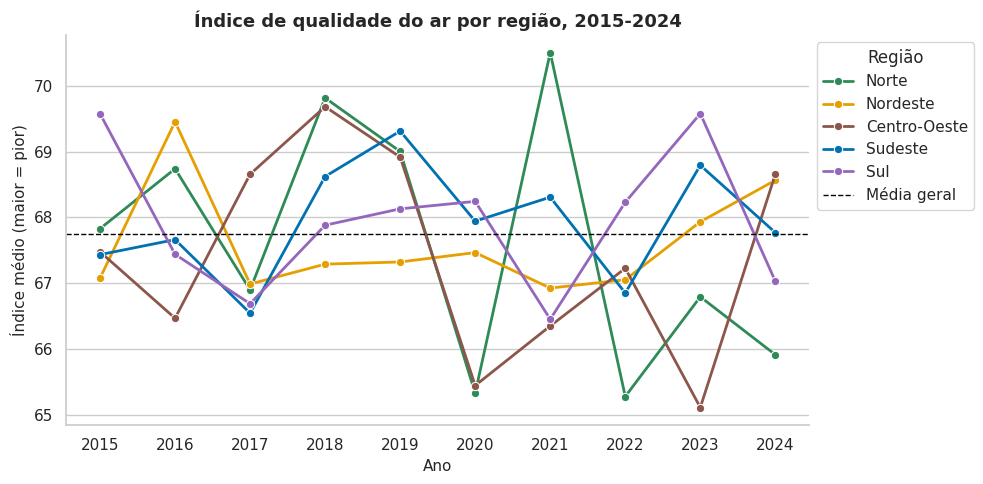

In [22]:
anual_regiao = df.groupby(['ano', 'regiao'])['indice_qualidade_ar'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=anual_regiao, x='ano', y='indice_qualidade_ar', hue='regiao', hue_order=list(CORES_REGIAO),
             palette=CORES_REGIAO, marker='o', linewidth=2, ax=ax)
ax.axhline(MEDIA_GERAL, color='black', linestyle='--', linewidth=1, label='Média geral')
ax.set_title('Índice de qualidade do ar por região, 2015-2024')
ax.set_xlabel('Ano')
ax.set_ylabel('Índice médio (maior = pior)')
ax.set_xticks(range(2015, 2025))
ax.legend(title='Região', loc='upper left', bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'evolucao_anual_regiao')
plt.show()

### 9.3 Ranking de cidades: as 10 mais e as 10 menos poluídas

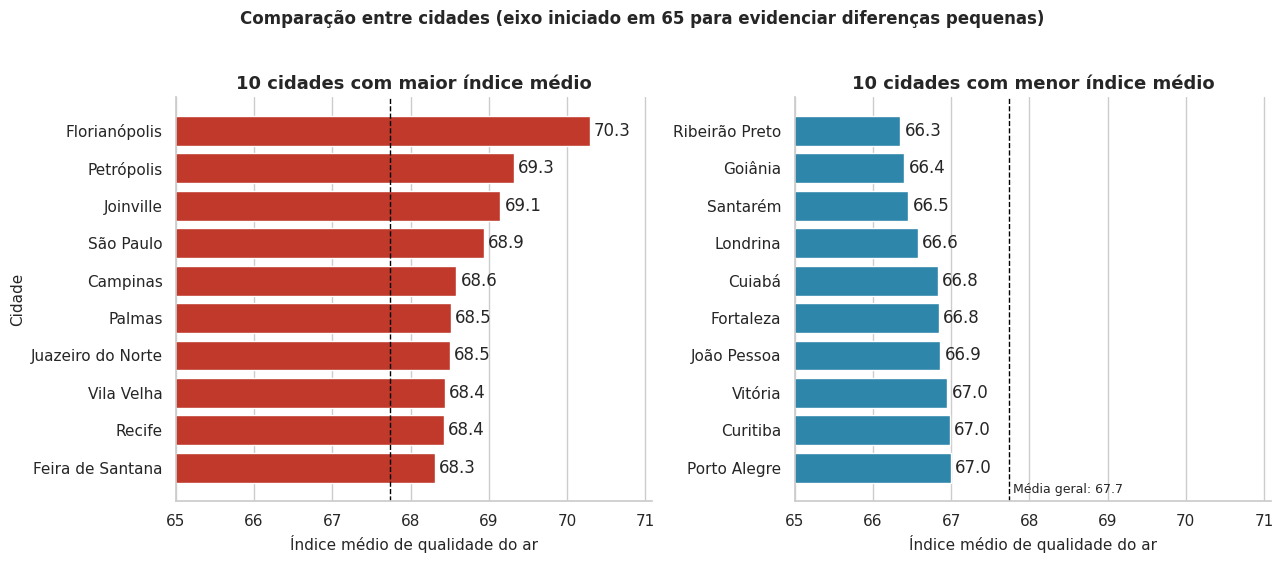

In [23]:
piores = resumo_cidade.head(10).iloc[::-1]
melhores = resumo_cidade.tail(10).sort_values('iqa_medio', ascending=False)
limite_inferior = 65

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
for ax, dados, cor, titulo in [(axes[0], piores, COR_DESTAQUE, '10 cidades com maior índice médio'),
                               (axes[1], melhores, COR_APOIO, '10 cidades com menor índice médio')]:
    barras = ax.barh(dados['cidade'], dados['iqa_medio'], color=cor)
    ax.bar_label(barras, fmt='%.1f', padding=3)
    ax.axvline(MEDIA_GERAL, color='black', linestyle='--', linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel('Índice médio de qualidade do ar')
    ax.grid(axis='x', visible=True)
    ax.grid(axis='y', visible=False)
axes[0].set_ylabel('Cidade')
axes[0].set_xlim(limite_inferior, resumo_cidade['iqa_medio'].max() + 0.8)
axes[1].text(MEDIA_GERAL + 0.05, 0.02, f'Média geral: {MEDIA_GERAL:.1f}', fontsize=9, transform=axes[1].get_xaxis_transform())
fig.suptitle('Comparação entre cidades (eixo iniciado em 65 para evidenciar diferenças pequenas)', y=1.02, fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'ranking_cidades')
plt.show()

### 9.4 Comparação entre regiões: índice médio e percentual de períodos críticos

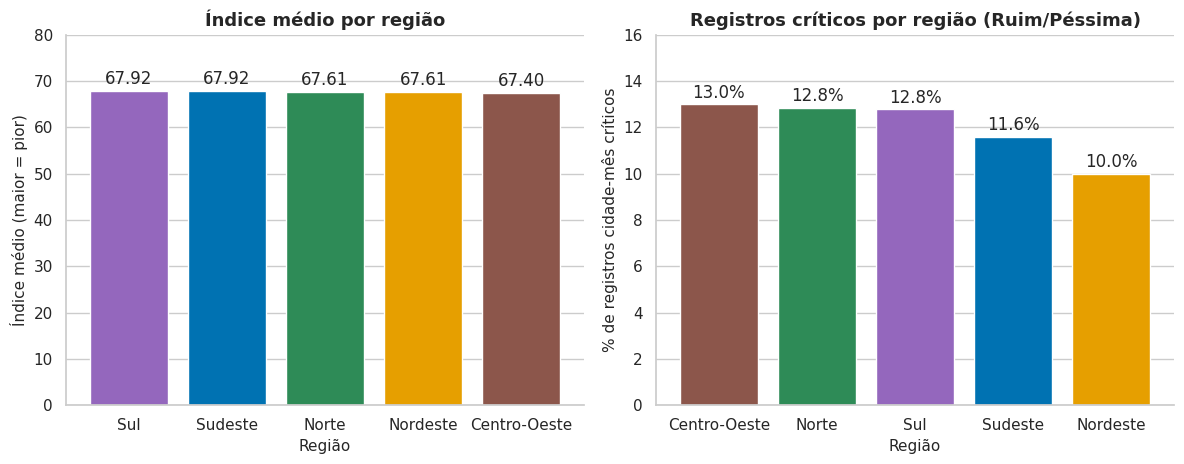

In [24]:
ordem_regiao = list(resumo_regiao.sort_values('iqa_medio', ascending=False).index)
ordem_crit = list(resumo_regiao.sort_values('pct_critico', ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
b1 = axes[0].bar(ordem_regiao, resumo_regiao.loc[ordem_regiao, 'iqa_medio'], color=[CORES_REGIAO[r] for r in ordem_regiao])
axes[0].bar_label(b1, fmt='%.2f', padding=2)
axes[0].set_title('Índice médio por região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Índice médio (maior = pior)')
axes[0].set_ylim(0, 80)

b2 = axes[1].bar(ordem_crit, resumo_regiao.loc[ordem_crit, 'pct_critico'], color=[CORES_REGIAO[r] for r in ordem_crit])
axes[1].bar_label(b2, fmt='%.1f%%', padding=2)
axes[1].set_title('Registros críticos por região (Ruim/Péssima)')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('% de registros cidade-mês críticos')
axes[1].set_ylim(0, 16)
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'comparacao_regioes')
plt.show()

### 9.5 Análise de poluentes: frequência e contribuição ao índice

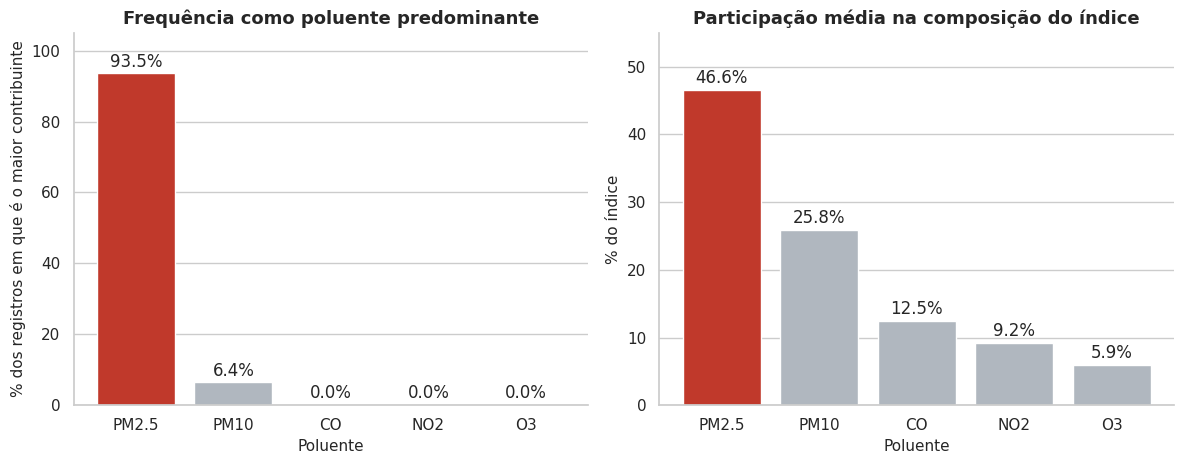

In [25]:
freq = df['poluente_predominante'].value_counts(normalize=True).mul(100).reindex(['PM2.5', 'PM10', 'CO', 'NO2', 'O3']).fillna(0)
part = participacao.reindex(['PM2.5', 'PM10', 'CO', 'NO2', 'O3'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
b1 = axes[0].bar(freq.index, freq.values, color=[COR_DESTAQUE if p == freq.idxmax() else '#B0B7BF' for p in freq.index])
axes[0].bar_label(b1, fmt='%.1f%%', padding=2)
axes[0].set_title('Frequência como poluente predominante')
axes[0].set_xlabel('Poluente')
axes[0].set_ylabel('% dos registros em que é o maior contribuinte')
axes[0].set_ylim(0, 105)

b2 = axes[1].bar(part.index, part.values, color=[COR_DESTAQUE if p == part.idxmax() else '#B0B7BF' for p in part.index])
axes[1].bar_label(b2, fmt='%.1f%%', padding=2)
axes[1].set_title('Participação média na composição do índice')
axes[1].set_xlabel('Poluente')
axes[1].set_ylabel('% do índice')
axes[1].set_ylim(0, 55)
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'poluentes')
plt.show()

### 9.6 Distribuição do índice e níveis de qualidade ao longo dos anos

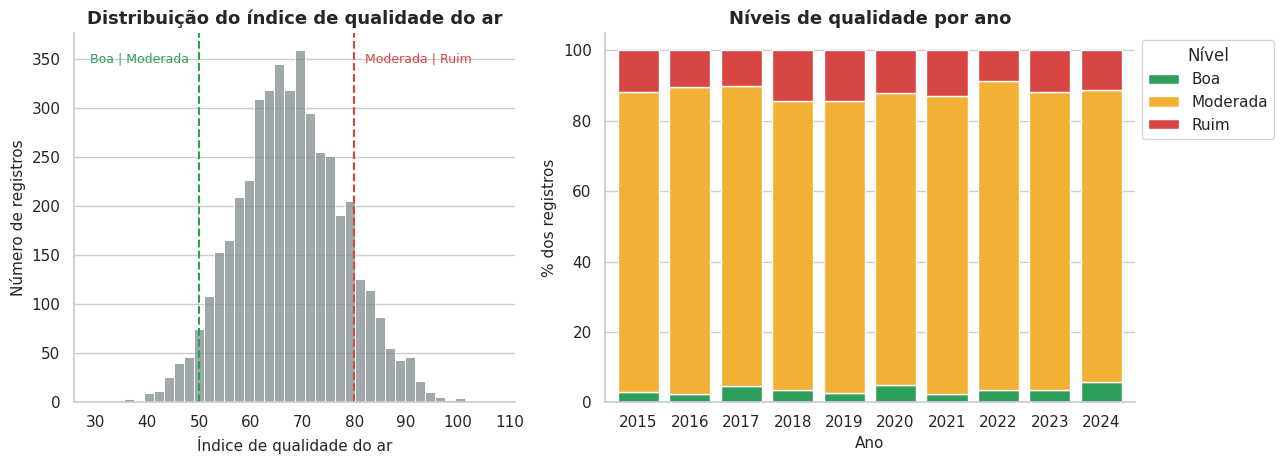

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [1, 1.2]})

sns.histplot(df['indice_qualidade_ar'], bins=40, color='#7F8C8D', edgecolor='white', ax=axes[0])
axes[0].axvline(50, color=CORES_NIVEL['Boa'], linestyle='--', linewidth=1.5)
axes[0].axvline(80, color=CORES_NIVEL['Ruim'], linestyle='--', linewidth=1.5)
axes[0].text(48, axes[0].get_ylim()[1] * 0.92, 'Boa | Moderada', ha='right', fontsize=9, color=CORES_NIVEL['Boa'])
axes[0].text(82, axes[0].get_ylim()[1] * 0.92, 'Moderada | Ruim', ha='left', fontsize=9, color=CORES_NIVEL['Ruim'])
axes[0].set_title('Distribuição do índice de qualidade do ar')
axes[0].set_xlabel('Índice de qualidade do ar')
axes[0].set_ylabel('Número de registros')

niveis_ano = pd.crosstab(df['ano'], df['nivel_qualidade'], normalize='index').mul(100)[['Boa', 'Moderada', 'Ruim']]
niveis_ano.plot(kind='bar', stacked=True, color=[CORES_NIVEL[n] for n in niveis_ano.columns], width=0.8, ax=axes[1])
axes[1].set_title('Níveis de qualidade por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('% dos registros')
axes[1].set_xticklabels(niveis_ano.index, rotation=0)
axes[1].legend(title='Nível', loc='upper left', bbox_to_anchor=(1, 1))
axes[1].grid(axis='x', visible=False)
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'distribuicao_niveis')
plt.show()

### 9.7 Heatmap mensal: sazonalidade (interativo)

In [27]:
mapa_mes_ano = df.pivot_table(index='ano', columns='mes', values='indice_qualidade_ar', aggfunc='mean')
mapa_mes_ano.columns = [meses_pt[m] for m in mapa_mes_ano.columns]

fig = go.Figure(go.Heatmap(z=mapa_mes_ano.values, x=list(mapa_mes_ano.columns), y=[str(a) for a in mapa_mes_ano.index],
                           colorscale='YlOrRd', colorbar=dict(title='Índice médio'),
                           text=np.round(mapa_mes_ano.values, 1), texttemplate='%{text}',
                           hovertemplate='%{y} - %{x}<br>Índice médio: %{z:.2f}<extra></extra>'))
fig.update_layout(title='Heatmap mensal do índice de qualidade do ar (média das 37 cidades)',
                  xaxis_title='Mês', yaxis_title='Ano', yaxis=dict(autorange='reversed'),
                  template='plotly_white', height=480)
fig.show()

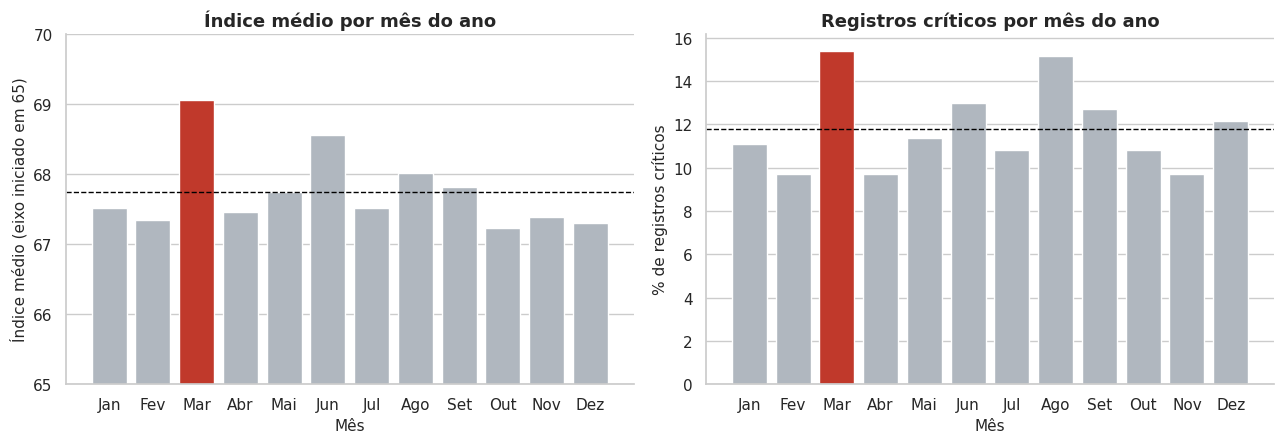

In [28]:
# Perfil sazonal: índice médio e percentual de registros críticos por mês
perfil = resumo_mes.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cores_mes = [COR_DESTAQUE if v == perfil['iqa_medio'].max() else '#B0B7BF' for v in perfil['iqa_medio']]
axes[0].bar(perfil['mes_nome'], perfil['iqa_medio'], color=cores_mes)
axes[0].axhline(MEDIA_GERAL, color='black', linestyle='--', linewidth=1)
axes[0].set_ylim(65, 70)
axes[0].set_title('Índice médio por mês do ano')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Índice médio (eixo iniciado em 65)')

cores_crit = [COR_DESTAQUE if v == perfil['pct_critico'].max() else '#B0B7BF' for v in perfil['pct_critico']]
axes[1].bar(perfil['mes_nome'], perfil['pct_critico'], color=cores_crit)
axes[1].axhline(100 * df['critico'].mean(), color='black', linestyle='--', linewidth=1)
axes[1].set_title('Registros críticos por mês do ano')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('% de registros críticos')
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'perfil_sazonal')
plt.show()

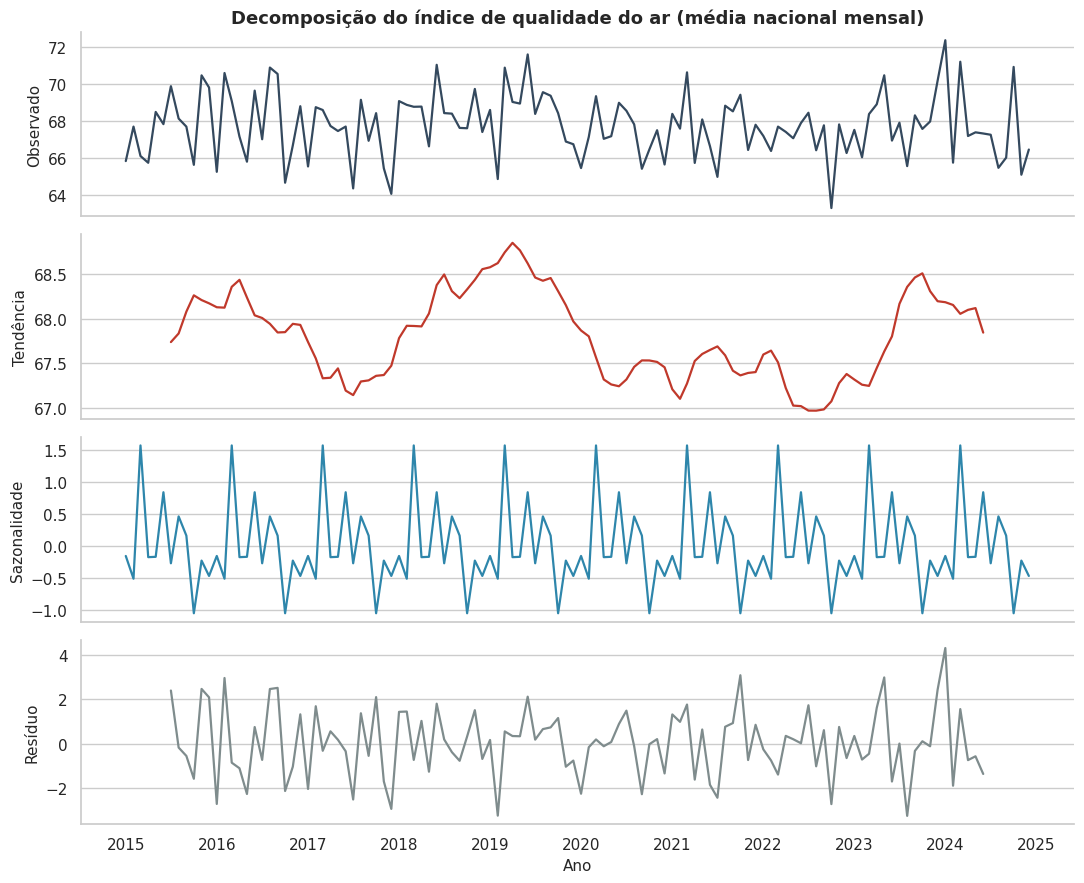

In [29]:
# Decomposição da série temporal (observado, tendência, sazonalidade e resíduo)
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
componentes = [('Observado', serie, '#34495E'), ('Tendência', tendencia, COR_DESTAQUE),
               ('Sazonalidade', sazonal, COR_APOIO), ('Resíduo', residuo, '#7F8C8D')]
for ax, (nome, valores, cor) in zip(axes, componentes):
    ax.plot(valores.index, valores.values, color=cor, linewidth=1.6)
    ax.set_ylabel(nome)
axes[0].set_title('Decomposição do índice de qualidade do ar (média nacional mensal)')
axes[-1].set_xlabel('Ano')
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'decomposicao_serie')
plt.show()

### 9.8 Dispersão: clima x poluição

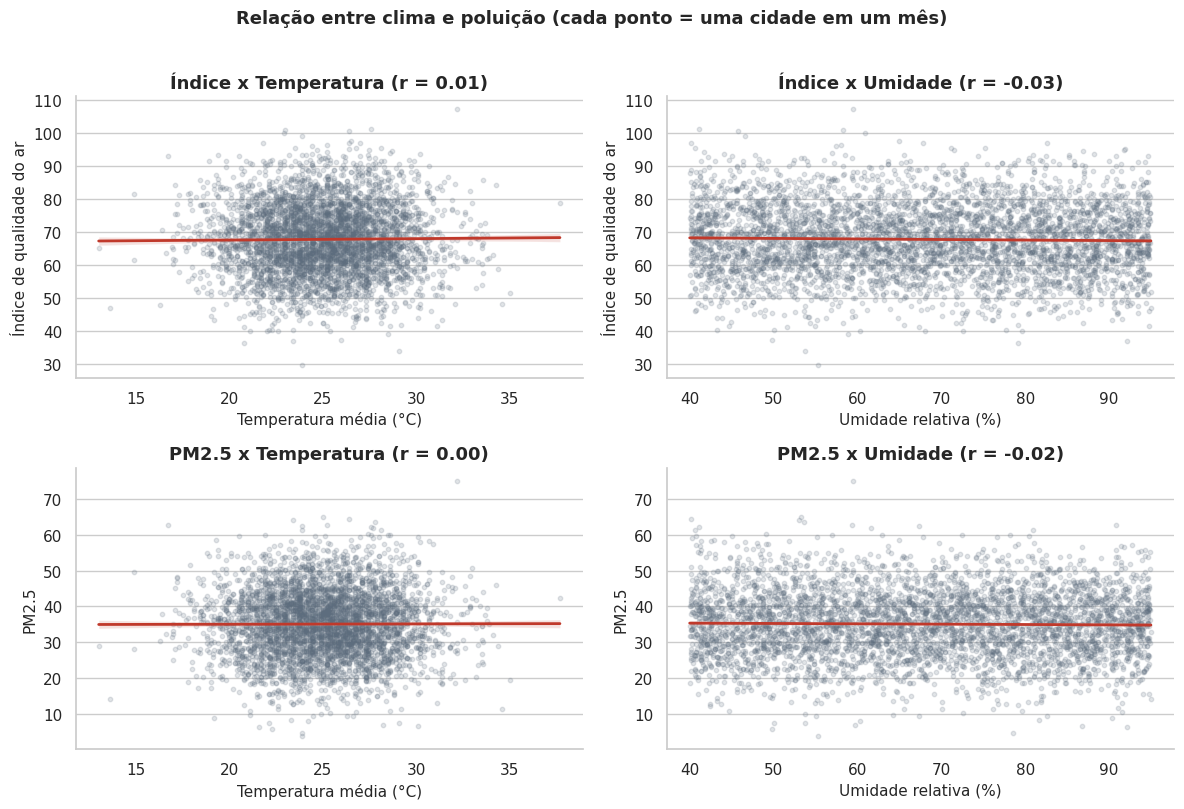

In [30]:
pares = [('temperatura_media', 'indice_qualidade_ar', 'Temperatura média (°C)', 'Índice de qualidade do ar', 'Índice x Temperatura'),
         ('umidade', 'indice_qualidade_ar', 'Umidade relativa (%)', 'Índice de qualidade do ar', 'Índice x Umidade'),
         ('temperatura_media', 'pm25', 'Temperatura média (°C)', 'PM2.5', 'PM2.5 x Temperatura'),
         ('umidade', 'pm25', 'Umidade relativa (%)', 'PM2.5', 'PM2.5 x Umidade')]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (x, y, rx, ry, titulo) in zip(axes.ravel(), pares):
    r, p = stats.pearsonr(df[x], df[y])
    sns.regplot(data=df, x=x, y=y, scatter_kws={'alpha': 0.18, 's': 10, 'color': '#5D6D7E'},
                line_kws={'color': COR_DESTAQUE, 'linewidth': 2}, ax=ax)
    ax.set_title(f'{titulo} (r = {r:.2f})')
    ax.set_xlabel(rx)
    ax.set_ylabel(ry)
fig.suptitle('Relação entre clima e poluição (cada ponto = uma cidade em um mês)', y=1.01, fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
salvar_figura(fig, 'dispersao_clima')
plt.show()

### 9.9 Matriz de correlação

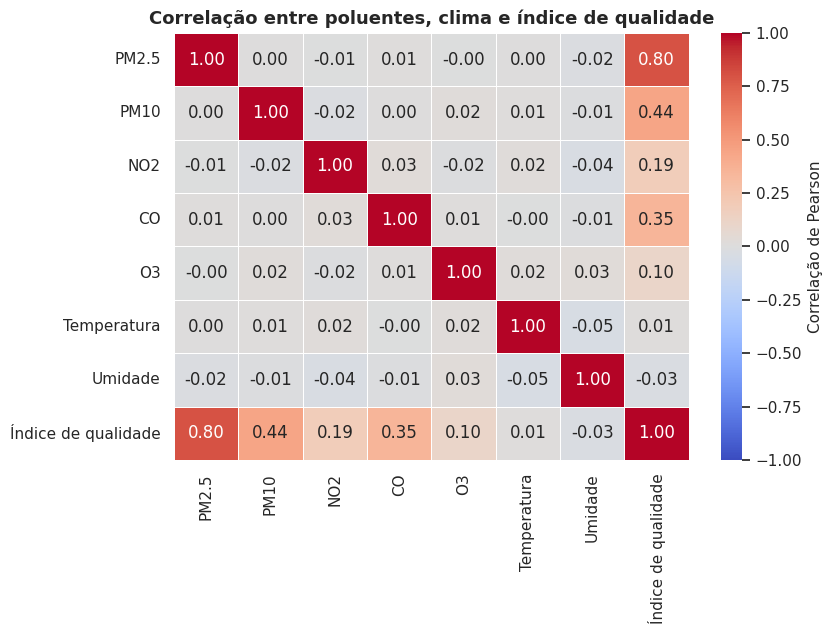

In [31]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Correlação de Pearson'}, ax=ax)
ax.set_title('Correlação entre poluentes, clima e índice de qualidade')
plt.tight_layout()
salvar_figura(fig, 'matriz_correlacao')
plt.show()

### 9.10 Tabelas dinâmicas para exploração detalhada

In [32]:
pivo_regiao_ano = df.pivot_table(index='regiao', columns='ano', values='indice_qualidade_ar',
                                 aggfunc='mean', margins=True, margins_name='Brasil')
print('Índice médio por região e ano:')
display(pivo_regiao_ano.style.background_gradient(cmap='YlOrRd', axis=None).format('{:.1f}'))

pivo_regiao_nivel = (pd.crosstab(df['regiao'], df['nivel_qualidade'], normalize='index')
                       .mul(100)[['Boa', 'Moderada', 'Ruim']])
print('\nDistribuição percentual dos níveis de qualidade por região:')
display(pivo_regiao_nivel.style.background_gradient(cmap='Blues', axis=None).format('{:.1f}%'))

pivo_cidade_estacao = df.pivot_table(index='cidade', columns='estacao', values='indice_qualidade_ar', aggfunc='mean')
pivo_cidade_estacao = pivo_cidade_estacao[['Verão', 'Outono', 'Inverno', 'Primavera']].loc[resumo_cidade['cidade'].head(10)]
print('\nÍndice médio por estação nas 10 cidades com maior índice:')
display(pivo_cidade_estacao.style.background_gradient(cmap='YlOrRd', axis=None).format('{:.1f}'))

Índice médio por região e ano:


ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Brasil
regiao,,,,,,,,,,,
Centro-Oeste,67.5,66.5,68.7,69.7,68.9,65.4,66.4,67.2,65.1,68.7,67.4
Nordeste,67.1,69.5,67.0,67.3,67.3,67.5,66.9,67.1,67.9,68.6,67.6
Norte,67.8,68.7,66.9,69.8,69.0,65.3,70.5,65.3,66.8,65.9,67.6
Sudeste,67.4,67.7,66.5,68.6,69.3,67.9,68.3,66.9,68.8,67.8,67.9
Sul,69.6,67.4,66.7,67.9,68.1,68.2,66.5,68.2,69.6,67.0,67.9
Brasil,67.8,68.0,67.0,68.5,68.6,67.2,67.7,67.0,68.0,67.7,67.7



Distribuição percentual dos níveis de qualidade por região:


nivel_qualidade,Boa,Moderada,Ruim
regiao,,,
Centro-Oeste,4.7%,82.3%,13.0%
Nordeste,3.3%,86.7%,10.0%
Norte,3.3%,83.8%,12.8%
Sudeste,3.6%,84.8%,11.6%
Sul,3.5%,83.8%,12.8%



Índice médio por estação nas 10 cidades com maior índice:


estacao,Verão,Outono,Inverno,Primavera
cidade,,,,
Florianópolis,71.0,68.9,71.9,69.3
Petrópolis,68.9,68.3,69.0,71.1
Joinville,69.1,69.3,72.0,66.2
São Paulo,68.4,69.8,70.7,66.8
Campinas,68.4,68.7,68.7,68.6
Palmas,68.5,67.4,70.4,67.7
Juazeiro do Norte,66.0,67.2,71.6,69.2
Vila Velha,71.1,68.2,66.0,68.4
Recife,69.1,70.6,68.4,65.6


# 10. Interpretação dos Resultados

> **Observação metodológica:** a base é **simulada**. Por isso, os resultados descrevem o comportamento dos dados fornecidos e não devem ser lidos como a situação real da qualidade do ar de cada cidade.

### 10.1 Quais cidades apresentam pior qualidade do ar?
* O índice médio geral é **67,74**, em uma escala em que 80 ou mais é classificado como "Ruim". Isso coloca a maioria dos registros no nível **Moderada (84,6%)**.
* As cidades com maior índice médio são **Florianópolis (70,29)**, **Petrópolis (69,32)**, **Joinville (69,15)**, **São Paulo (68,94)** e **Campinas (68,59)**. As melhores são **Ribeirão Preto (66,35)**, **Goiânia (66,40)**, **Santarém (66,45)**, **Londrina (66,57)** e **Cuiabá (66,83)**.
* Florianópolis e Joinville se destacam também no percentual de registros críticos (**18,3% e 19,2%**, contra 11,8% na média), o que as torna as cidades que mais exigem atenção quando os dois critérios são combinados.
* **Ressalva importante:** a diferença entre a melhor e a pior cidade é de apenas **3,9 pontos**, enquanto o índice de uma mesma cidade varia, em média, cerca de **10 pontos** de um mês para o outro. O teste ANOVA (p = 0,59) indica que **não há diferença estatisticamente significativa entre as cidades**. O ranking é útil como ordenação, mas é pouco robusto.

### 10.2 Existem períodos mais críticos?
* Por mês, **março** tem o maior índice médio (69,06) e o maior percentual de registros críticos (15,4%), seguido de **agosto** (15,1%) e **junho** (13,0%). Os menores percentuais ocorrem em fevereiro, abril e novembro (9,7%).
* Por ano, **2018 e 2019** concentram mais registros críticos (14,4% cada) e **2022**, menos (8,6%).
* **Não há sazonalidade relevante.** Na série nacional, o perfil sazonal tem amplitude de 2,6 pontos entre o mês mais alto (março) e o mais baixo (outubro), mas a força da sazonalidade na decomposição é baixa (0,16) e a diferença entre os meses **não é estatisticamente significativa** (ANOVA sobre a série nacional mensal: p = 0,44; sobre os registros das cidades: p = 0,38). Os resultados por ano (p = 0,20) e por estação (p = 0,25) seguem o mesmo padrão.
* No heatmap mensal, o mês de maior índice muda de um ano para o outro e a correlação média entre os perfis mensais de anos diferentes é de apenas 0,02. Ou seja, não há um padrão mensal que se repita ao longo dos anos.

### 10.3 Quais poluentes são mais frequentes?
* O índice é composto por pesos fixos sobre os poluentes (PM2.5 = 0,90; PM10 = 0,25; NO2 = 0,25; CO = 8,00; O3 = 0,10), com R² de praticamente 1.
* O **PM2.5 é o poluente predominante**: responde por cerca de **46,6%** do valor do índice e é o maior contribuinte em **93,5%** dos registros. O PM10 aparece em seguida, com 25,8% do índice e predominância em 6,4% dos registros. CO, NO2 e O3 respondem por 12,5%, 9,2% e 5,9%.
* Essa relação também aparece na correlação: o índice se correlaciona fortemente com o PM2.5 (**r = 0,80**), moderadamente com PM10 (0,44) e CO (0,35) e fracamente com NO2 (0,19) e O3 (0,10). Os poluentes são praticamente independentes entre si.
* Do ponto de vista ambiental, isso é coerente com a literatura: o material particulado fino é o poluente de maior impacto na saúde e a principal referência das diretrizes de qualidade do ar da OMS. Por isso, ações de controle de emissões que reduzem PM2.5 (frota a diesel, queimadas, indústrias) tendem a ter o maior efeito sobre o índice.

### 10.4 Existe relação entre clima e poluição?
* **Não há relação relevante.** Para o índice e para o PM2.5, nenhuma correlação com temperatura ou umidade é significativa: índice x temperatura r = 0,01 (p = 0,42), índice x umidade r = -0,03 (p = 0,09), PM2.5 x temperatura r = 0,00 e PM2.5 x umidade r = -0,02. Apenas NO2 (r = -0,04) e O3 (r = 0,03) têm correlação estatisticamente significativa com a umidade, mas de magnitude desprezível (explicam menos de 0,2% da variação), efeito do grande número de registros. A reta de tendência nos gráficos de dispersão é praticamente horizontal.
* O resultado contraria a expectativa ambiental (menor umidade e maior temperatura favorecendo acúmulo de poluentes e formação de ozônio). Na base simulada, as variáveis climáticas foram geradas de forma independente dos poluentes e as temperaturas médias das cidades são muito próximas (24,4 °C a 25,6 °C), o que limita a análise.

### 10.5 Há melhora ou piora ao longo do tempo?
* O índice médio anual oscila entre **66,96 (2022)** e **68,59 (2019)**. A tendência linear é de **-0,03 ponto por ano** (p = 0,67), ou seja, **estabilidade**. A média móvel de 12 meses oscila entre cerca de 67,0 e 68,9, sem trajetória de piora ou melhora, e a autocorrelação mensal é praticamente nula (-0,07), ou seja, um mês crítico não tende a ser seguido de outro.

### 10.6 Quais regiões apresentam maior concentração de poluentes?
* **Sul** e **Sudeste** têm os maiores índices médios (ambas **67,92**, empate técnico), seguidas de Norte (67,61), Nordeste (67,61) e Centro-Oeste (67,40). A diferença entre extremos é de apenas 0,5 ponto (ANOVA p = 0,80).
* Pelo percentual de registros críticos, o ranking muda: **Centro-Oeste (13,0%)**, Norte e Sul (12,8%), Sudeste (11,6%) e Nordeste (10,0%). O teste qui-quadrado (p = 0,27) indica que a diferença não é estatisticamente significativa.
* Não há, portanto, uma região que se destaque de forma consistente. A escolha da "região mais afetada" depende do critério e deve ser lida com cautela.

### 10.7 Limitações
* Base **simulada**, com granularidade mensal (sem dados diários nem de estações de monitoramento).
* Unidades de medida dos poluentes não informadas, impossibilitando comparação com limites legais (OMS, CONAMA).
* Ausência de padrões temporais, regionais e climáticos significativos, o que limita a capacidade explicativa; nenhuma cidade atingiu o nível "Péssima".

# 11. Conclusão

**Principais descobertas**

1. O índice médio de qualidade do ar é de **67,74** e **11,8%** dos registros cidade-mês são críticos (nível Ruim); nenhum atingiu o nível Péssima.
2. O **PM2.5 é o poluente predominante**, responsável por cerca de 47% do índice e pelo maior peso em mais de 93% dos registros.
3. **Florianópolis** e **Joinville** combinam os maiores índices médios e os maiores percentuais de registros críticos; **Ribeirão Preto**, **Goiânia** e **Santarém** apresentam os menores índices.
4. **Não há evidência estatística** de sazonalidade, tendência de piora ou melhora, diferença entre regiões ou relação com temperatura e umidade. As variações observadas são compatíveis com variação aleatória mensal.

**Resposta à pergunta central**

As cidades que mais exigem atenção ambiental são **Florianópolis, Joinville, Petrópolis e São Paulo**, e o poluente que deve orientar as ações é o **PM2.5**. As diferenças entre cidades são pequenas diante da variação mensal e não há períodos do ano ou regiões consistentemente piores.

**Decisões possíveis com base nos dados**

* Priorizar o monitoramento e o controle de emissões de **PM2.5** nas cidades com maiores índices e percentuais de registros críticos.
* Manter vigilância contínua ao longo do ano em vez de campanhas sazonais, já que não há mês ou estação que se destaque.
* Acompanhar a evolução dos percentuais de registros críticos como indicador de desempenho de políticas de controle de emissões.

**Limitações e próximos passos**

* Validar os achados com **dados reais**, de granularidade diária e por estação de monitoramento, e com unidades de medida definidas para comparação com limites da OMS e do CONAMA.
* Incorporar variáveis explicativas (frota veicular, atividade industrial, focos de queimada, precipitação).
* Disponibilizar a análise em um **dashboard interativo (Streamlit)** com filtros por ano, mês, região, estado, cidade e nível de qualidade, e publicar o projeto no GitHub e no GitHub Pages.